# Semana 3 -  Teste de Hipótese e Previsão de Resposta

Ligas de silício-germânio são usadas em certos tipos de células solares. O trabalho “*Silicon--germanium films deposited by low-frequenc plasma-enhanced chemical vapor deposition”* (J. of Material Res., 2006: 88-104) tratou a respeito de um estudo de diversas propriedades estruturais e elétricas. 

Considere os dados a seguir sobre 

x = concentração de Ge na fase sólida (variando de 0 a 1) e,

y = posição do nível de Fermi (eV)

Um gráfico de dispersão mostra uma relação linear substancial. 

In [2]:
#@title Tabela de dados
from tabulate import tabulate
table = [["x",  0, 0.42, 0.23, 0.33, 0.62, 0.60, 0.45, 0.87, 0.90, 0.79, 1, 1, 1],
         ["y", 0.62, 0.53, 0.61, 0.59, 0.50, 0.55, 0.59, 0.31, 0.43, 0.46, 0.23, 0.22, 0.19]]
print(tabulate(table))

-  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----
x  0     0.42  0.23  0.33  0.62  0.6   0.45  0.87  0.9   0.79  1     1     1
y  0.62  0.53  0.61  0.59  0.5   0.55  0.59  0.31  0.43  0.46  0.23  0.22  0.19
-  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----  ----


Obtenha a curva de regressão e os valores necessários para responder as seguintes questões:

**3a.**	Obtenha uma estimativa intervalar da mudança esperada na posição do nível de Fermi associada com um aumento de 0,1 nas concentrações de Ge e interprete seu resultado. 

**3b.** Obtenha uma estimativa de intervalo para a média da posição do nível de Fermi quando a concentração é 0,50 e interprete seu resultado. 

**3c.** Obtenha um intervalo dos valores plausíveis para a posição resultante de uma única observação a ser feita quando a concentração é 0,50, interprete seu intervalo e o compare ao intervalo de (3b). 

**3d.** Obtenha IC simultâneos para a posição esperada quando a concentração é 0,3, 0,5 e 0,7; o nível de confiança conjunto deve ser de pelo menos 97%. 

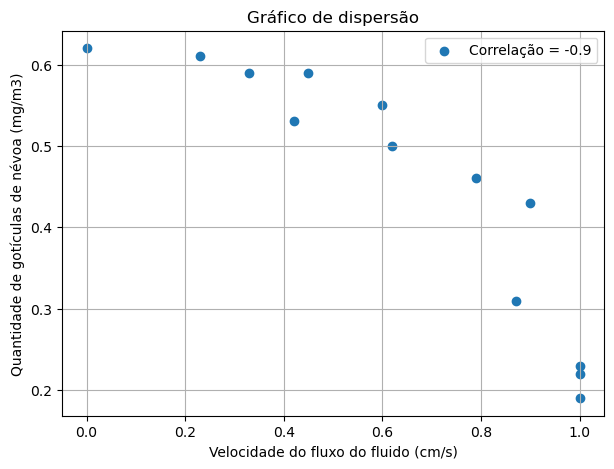

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Primeiro definir os dados
lstx2 = (0, 0.42, 0.23, 0.33, 0.62, 0.60, 0.45, 0.87, 0.90, 0.79, 1, 1, 1)
lsty2= (0.62, 0.53, 0.61, 0.59, 0.50, 0.55, 0.59, 0.31, 0.43, 0.46, 0.23, 0.22, 0.19 )
# Construir o DataFrame e nomear as colunas
df = pd.DataFrame(list(zip(lstx2, lsty2)),
               columns =["x","y"])
#diagrama de dispersão
x=df['x']
y=df['y']
plt.rcParams.update({'figure.figsize':(7,5), 'figure.dpi':100})
plt.scatter(x,y, label=f'Correlação = {np.round(np.corrcoef(x,y)[0,1], 2)}')
plt.xlabel('Velocidade do fluxo do fluido (cm/s)')
plt.ylabel('Quantidade de gotículas de névoa (mg/m3)') 
plt.title('Gráfico de dispersão')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
import statsmodels.api as sm
#Proceso de regressão 
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     44.43
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           3.53e-05
Time:                        11:33:53   Log-Likelihood:                 16.530
No. Observations:                  13   AIC:                            -29.06
Df Residuals:                      11   BIC:                            -27.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7217      0.046     15.753      0.0

## Resposta 3a.

Obtenha uma estimativa intervalar da mudança esperada na posição do nível de Fermi associada com um aumento de 0,1 nas concentrações de Ge e interprete seu resultado.

🤔💭 O qué preciso calcular? "estimativa intervalar da mudança esperada na posição do nível de Fermi associada com um aumento de 0,1 nas concentrações de Ge#

🙋 Y -> posição do nível de Fermi e X-> concentração de Ge na fase sólida.
A mudança de Y associada a um aumento de 0,1 em x pode ser descrita por um parâmetro, qual?

🤔💭 $\beta_1$?

Devo calcular o intervalo de confiança de $\beta_1$

IC de $\beta_1= \hat{\beta}_1 \pm t_{\frac{\alpha}{2},n-2} s_{\hat{\beta}_1}  $

In [11]:
#b1
b=modelo.params


In [17]:
b

const    0.721719
x       -0.432685
dtype: float64

In [19]:
b0=b.const
b1=b.x

In [20]:
#usar a tabela tstudent pata t
from scipy.stats import t
alpha = 0.05  # nível de significia = 5% 
df = len(x) - 2 # graus de liberdade (Número de amostras menos dois)                                     
#
v = t.ppf(1 - alpha/2, df) 
ta2=v
print(f't=: {v}') 

t=: 2.200985160091639


In [22]:
sb=modelo.bse #desvio padrão


In [23]:
sb

const    0.045814
x        0.064910
dtype: float64

In [24]:
sb0=sb.const   #desvio padrão de b0
sb1=sb.x       #desvio padrão de b1

In [25]:
#IC de b1
IC2a1=([b1-ta2*sb1,b1+ta2*sb1])
IC2a1

[np.float64(-0.575551343333075), np.float64(-0.28981814883860113)]

O intervalo de confiança de $\beta_1$ a 95% é (-0.5755, -0.2898)

## Resposta 3b. 
Obtenha uma estimativa de intervalo para a média da posição do nível de Fermi quando a concentração é 0,50 e interprete seu resultado.

✌ Y -> posição do nível de Fermi e X-> concentração de Ge na fase sólida.

🤔💭 O que é a estimativa de intervalo para a média da posição do nível de Fermi, quando a concentração é 0,50 

🙋 Estimativa de Y para x=0,5, ou seja o intervalo de estimado de Y para um único valor de x.

$\mu_{Y,0.5}=\beta_0 + \beta_1 x^*=0,7217 - 0,4327 (0,5)$


In [27]:
uy05=b0+b1*0.5
uy05

np.float64(0.5053762242928298)

🤔💭 Qual é a equação para o intervalo estimado de uma única observação?

IC de $\mu_{Y,0.5}$ pode se calcular com $\hat{Y} \pm t_{\frac{\alpha}{2},n-2} s_{\hat{Y}} $

e $s_{\hat{Y}}=s\sqrt(\frac{1}{n}+\frac{(x^* -\bar{x})^2}{S_{XX}})$



In [29]:
#O seguinte código pode também ser usado previamente para calcular SQE, SQT, SQR e r2 (Alternativa 2)
# fonte: Adaptado de https://www.geeksforgeeks.org/sum-function-python/
def linreg(X, Y):
    """
    retorna a solução b0 e b1 para a reta y = b0 + b1x e todas as somatórias necessárias
    """
    N = len(X)
    Sx = Sy = Sxx = Syy = Sxy = 0.0
    for x, y in zip(X, Y):
        Sx = Sx + x           # Somatória do termos x
        Sy = Sy + y           # Somatória do termos y
        Sxx = Sxx + x*x       # Somatória do termos x^2
        Syy = Syy + y*y       # Somatória do termos y^2
        Sxy = Sxy + x*y       # Somatória do termos x vezes y
    det = Sxx * N - Sx * Sx   # variável auxiliar
    Sxxt= Sxx - Sx*Sx/N       # Termo Sxx
    Sxyt= Sxy - Sx*Sy/N       # Termo Sxy  
    Syyt= Syy - Sy*Sy/N       # Termo Syy  
    r=Sxyt/pow((Sxxt*Syyt), 1/2)
    return (Sxy * N - Sy * Sx)/det, (Sxx * Sy - Sx * Sxy)/det, Sx, Sy, Sxx,  Syy , Sxy, Sxxt, Sxyt, Syyt,r

In [30]:
df = pd.DataFrame(list(zip(lstx2, lsty2)),
               columns =["x","y"])
x=df['x']
y=df['y']
b1,b0,sox,soy,sox2,soy2,soxy,sxx,sxy,syy,corr = linreg(x,y)  
#Calcular SQE, SQT e SQR
sqe=syy-b1*sxy
sqt=syy
sqr=sqt-sqe
#Calcular variância estimada
s2=sqe/(len(y)-2)
#Calcular desvio padrão estimado
s=pow(s2,1/2)
#Calcular erro padrão
ebeta=s/pow(sxx,1/2)
print('Sxx= {0}, Syy {1}, Sxy {2}'.format(sxx,syy,sxy))
print('SQE= {0}, SQT {1}, SQR {2}'.format(sqe,sqt,sqr))
print('Variância estimada, s^2= {0}, Desvio padrão estimado, s= {1}'.format(s2,s))

Sxx= 1.2911692307692295, Syy 0.30156923076923103, Sxy -0.5586692307692305
SQE= 0.05984157650787639, SQT 0.30156923076923103, SQR 0.24172765426135465
Variância estimada, s^2= 0.005440143318897853, Desvio padrão estimado, s= 0.07375732722176051


In [31]:
xs=0.5 #x*
xm=x.mean()
n=modelo.df_resid + 2 #gl+2=n
xs,xm,n

(0.5, np.float64(0.6315384615384616), np.float64(13.0))

In [32]:
sy=s*pow(((1/n)+(xs-xm)*(xs-xm)/sxx),1/2)
sy

np.float64(0.022166944519205978)

In [33]:
#IC do valor esperado para um valor específico de x 
ICuy05=([uy05-ta2*sy,uy05+ta2*sy])
ICuy05

[np.float64(0.45658710836148275), np.float64(0.5541653402241769)]

$0.4566 < \mu_{Y,0.5} < 0.5542 $
## Resposta 3c.

2c. Obtenha um intervalo dos valores plausíveis para a posição resultante de uma única observação a ser feita quando a concentração é 0,50, interprete seu intervalo e o compare ao intervalo de (3b).

-> Intervalo de previsão de Y para x=0,5.

🤔💭 Qual é a equação para o intervalo de previsão?

IP de $Y_{0.5}$ pode se calcular com $\hat{Y} \pm t_{\frac{\alpha}{2},n-2} \sqrt{s^2+s^2_{\hat{Y}}} $



In [34]:
#valor de y-chapeu para uma única observação uy05 calculado em 2b
#ta2 valor t-student usado nos items anteriores
ip1y05=([uy05-ta2*pow((s2+sy*sy),1/2),uy05+ta2*pow((s2+sy*sy),1/2)])
ip1y05

[np.float64(0.33586440113613825), np.float64(0.6748880474495214)]

A 95% de confiança IP é $0.3359 < Y < 0.67489$

## Resposta 3d. 
Obtenha IC simultâneos para a posição esperada quando a concentração é 0,3, 0,5 e 0,7; o nível de confiança conjunto deve ser de pelo menos 97%.

🤔💭 posição esperada-> $\mu_{Y,x^*}$

Considerando que $100(1-k\alpha) \% \approx 97 \%$ 

Quantidade de observações simultâneas k=3 encontrar $\alpha$

$(1-k\alpha) = 0,97 $ 

$1-3\alpha = 0,97 $ 

$\alpha = \frac{0.03}{3} = 0,01$

Portanto cada observação deve ter um $\alpha = 0,01$, isto é o 99% de confiança

In [35]:
#100(1-alpha) de cada intervalor
0.99*0.99*0.99

0.9702989999999999

🤔💭 o que muda quando comparo com os IC calculados para 95%?

🙋 o valor obtido da tabela t-student

IC de $\mu_{Y,x^*}$ pode se calcular com $\hat{Y}_1 \pm t_{\frac{\alpha}{2},n-2} s_{\hat{Y}} $

e $s_{\hat{Y}}=s\sqrt(\frac{1}{n}+\frac{(x^* -\bar{x})^2}{S_{XX}})$

Observe que o valor de $s_{\hat{Y}}$  varia para cada valor de X porque depende do $x^*$

Assim precisa calcular o $\mu_{Y,x^*}$ e  o$s_{\hat{Y}}$ para cada amostra de x.

**Cálculos**

$\mu_{Y,x^*}$ 

Estimativa de Y para x=0,3, 0,5 e 0,7, ou seja o intervalo de estimado de Y para um único valor de cada x indicado.

$\mu_{Y,x^*}=\beta_0 + \beta_1 x^*=0,7217 - 0,4327 (x^*)$

$\mu_{Y,0.3}=\beta_0 + \beta_1 x_{0,3}=0,7217 - 0,4327 (0,3)$

$\mu_{Y,0.5}=\beta_0 + \beta_1 x_{0,5}=0,7217 - 0,4327 (0,5)$

$\mu_{Y,0.7}=\beta_0 + \beta_1 x_{0,7}=0,7217 - 0,4327 (0,7)$

In [36]:
x3 = 0.3
x5 = 0.5
x7 = 0.7
uy03d=b0+b1*x3
uy05d=b0+b1*x5
uy07d=b0+b1*x7
uy03d,uy05d,uy07d

(0.5919131735099966, 0.505376224292829, 0.4188392750756616)

In [37]:
#usar a tabela tstudent pata t
from scipy.stats import t
alpha = 0.01  # nível de significia = 5% 
df = len(x) - 2 # graus de liberdade (Número de amostras menos dois)                                     
#
v = t.ppf(1 - alpha/2, df) 
ta2d=v
print(f't=: {v}') 

t=: 3.105806515539281


In [38]:
#xm=x.mean()
#n=modelo.df_resid + 2 #gl+2=n
xm,n
sy3=s*pow(((1/n)+(x3-xm)*(x3-xm)/sxx),1/2)
sy5=s*pow(((1/n)+(x5-xm)*(x5-xm)/sxx),1/2)
sy7=s*pow(((1/n)+(x7-xm)*(x7-xm)/sxx),1/2)
sy3,sy5,sy7

(np.float64(0.02969165089768393),
 np.float64(0.022166944519205978),
 np.float64(0.020933715463280694))

In [39]:
#IC do valor esperado para várias observações x=0,3 0,5 e 0,7 
ICuy03d=([uy03d-ta2d*sy3,uy03d+ta2d*sy3])
ICuy05d=([uy05d-ta2d*sy5,uy05d+ta2d*sy5])
ICuy07d=([uy07d-ta2d*sy7,uy07d+ta2d*sy7])
print(f'O intervalo de confiança para y, x=0,3= {ICuy03d}')
print(f'O intervalo de confiança para y, x=0,5= {ICuy05d}')
print(f'O intervalo de confiança para y, x=0,7= {ICuy07d}')
#print('Os intervalos de confiança são: Para y, x=0,3= {0}, para y, x=0,5=  {1}, para y, x=0,7= {0} {2}'.format(ICuy03d,ICuy05d,ICuy07d))
#ICuy03d,ICuy05d,ICuy07d

O intervalo de confiança para y, x=0,3= [np.float64(0.49969665069485214), np.float64(0.6841296963251411)]
O intervalo de confiança para y, x=0,5= [np.float64(0.43652998357548134), np.float64(0.5742224650101767)]
O intervalo de confiança para y, x=0,7= [np.float64(0.35382320519535904), np.float64(0.48385534495596416)]
